# Week 4: Lab
# Text Classification with Naive Bayes
# Amrita Pudasaini

We take the **IMDB Top-1000 movie dataset**, create binary sentiment labels from the numeric ratings,
clean the movie overview text through a four-step NLP pipeline, and train a **Multinomial Naïve Bayes**
classifier to predict whether a film is viewed positively or negatively.

The notebook is structured in two parts:

| Part | Focus |
|------|-------|
| **Part 1** | Data loading → Label creation → Text preprocessing → Train/test split → Bag-of-Words features → Model training |
| **Part 2** | Evaluation: Accuracy · Precision/Recall/F1 · Confusion Matrix · ROC-AUC |


---
## 0 · Import Libraries

In [1]:
# ── Core data stack ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import re, warnings
warnings.filterwarnings('ignore')

# ── NLP toolkit ───────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import PorterStemmer

# ── Scikit-learn ──────────────────────────────────────────────────
from sklearn.model_selection        import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes            import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded ✔')

Libraries loaded ✔


---
# PART 1 — Data, Preprocessing & Model Training

## 1.1 · Load the Dataset

We read the CSV and immediately narrow our focus to three columns:
- `Series_Title` — film name (used only for display)
- `IMDB_Rating` — the numeric score we will convert into a label
- `Overview` — the text we will classify

Everything else (cast, gross revenue, poster links) is irrelevant to this task and is set aside.

In [3]:
df = pd.read_csv('imdb_top_1000.csv')

print(f'Rows × Columns : {df.shape}')
print(f'Missing values in Overview    : {df["Overview"].isnull().sum()}')
print(f'Missing values in IMDB_Rating : {df["IMDB_Rating"].isnull().sum()}')
print()
df[['Series_Title', 'IMDB_Rating', 'Overview']].head(6)

Rows × Columns : (1000, 16)
Missing values in Overview    : 0
Missing values in IMDB_Rating : 0



,Series_Title,IMDB_Rating,Overview
0,The Shawshank Redemption,9.3,Two imprisoned men bond over a number of years...
1,The Godfather,9.2,An organized crime dynasty's aging patriarch t...
2,The Dark Knight,9.0,When the menace known as the Joker wreaks havo...
3,The Godfather: Part II,9.0,The early life and career of Vito Corleone in ...
4,12 Angry Men,9.0,A jury holdout attempts to prevent a miscarria...
5,The Lord of the Rings: The Return of the King,8.9,Gandalf and Aragorn lead the World of Men agai...


## 1.2 · Visualise the Rating Distribution

Before we pick a label threshold we need to understand the spread of ratings.
The entire dataset sits between 7.6 and 9.3 — a compressed range by design (these are the
*top* 1000 films). The red dashed line at **8.0** is where we will cut the data into
Positive and Negative classes.

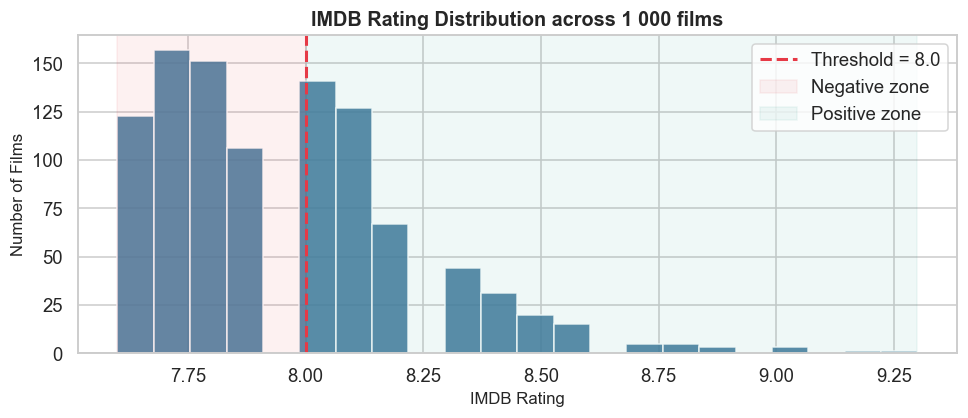

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df['IMDB_Rating'], bins=22, color='#457b9d', edgecolor='white', alpha=0.88)
ax.axvline(8.0, color='#e63946', linestyle='--', linewidth=2, label='Threshold = 8.0')

# Shade the two regions
ax.axvspan(df['IMDB_Rating'].min(), 8.0, alpha=0.07, color='#e63946', label='Negative zone')
ax.axvspan(8.0, df['IMDB_Rating'].max(), alpha=0.07, color='#2a9d8f', label='Positive zone')

ax.set_xlabel('IMDB Rating', fontsize=11)
ax.set_ylabel('Number of Films', fontsize=11)
ax.set_title('IMDB Rating Distribution across 1 000 films', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 1.3 · Label Engineering — Creating Sentiment Classes

The dataset has no ready-made "positive / negative" column.
We derive one from the numeric rating.

**Threshold choice — why 8.0?**
The dataset mean is ~7.95.  Anything rated ≥ 8.0 is generally regarded as *acclaimed*
(think Oscar winners, cult classics). Below 8.0 a film is still good but not outstanding.
Using the mean as a cut-point creates a natural, roughly balanced binary split without
artificially skewing either class.

Class counts:
sentiment
negative    537
positive    463

Balance ratio  negative : positive = 537 : 463


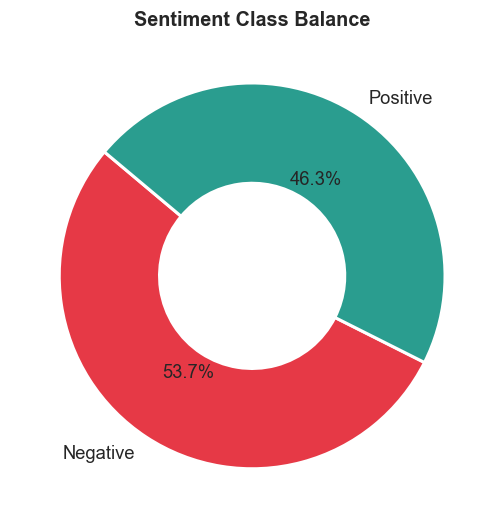

In [5]:
df['sentiment'] = df['IMDB_Rating'].apply(
    lambda r: 'positive' if r >= 8.0 else 'negative'
)

counts = df['sentiment'].value_counts()
print('Class counts:')
print(counts.to_string())
print(f'\nBalance ratio  negative : positive = {counts["negative"]} : {counts["positive"]}')

# Donut chart
fig, ax = plt.subplots(figsize=(5, 5))
wedge_props = dict(width=0.52, edgecolor='white', linewidth=2)
ax.pie(counts, labels=['Negative','Positive'], autopct='%1.1f%%',
       colors=['#e63946','#2a9d8f'], wedgeprops=wedge_props,
       startangle=140, textprops={'fontsize':12})
ax.set_title('Sentiment Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.4 · Text Preprocessing

Raw text is noisy. Before feeding it to any machine-learning model we need to
standardise and strip out everything that does not carry meaningful signal.
Think of preprocessing as *translating the text into the model's language*.

The pipeline runs in strict order — each step depends on the output of the previous one:

```
Raw overview
     │
     ▼  Step 1 ─ Lowercase            "Drama" → "drama"
     ▼  Step 2 ─ Remove non-alpha     "won't!" → "wont"
     ▼  Step 3 ─ Stopword removal     "is a very" → removed
     ▼  Step 4 ─ Porter stemming      "struggling" → "struggl"
     │
     ▼
Clean token string
```

**Why these four steps specifically?**

| Step | What it removes / standardises | Benefit for Naïve Bayes |
|------|-------------------------------|------------------------|
| Lowercase | Case variance | "Drama" and "drama" counted as one feature |
| Non-alpha strip | Punctuation, numbers | Reduces vocabulary noise |
| Stopwords | Filler words with no discriminative power | Shrinks feature space; speeds up training |
| Stemming | Morphological inflections | Consolidates related forms into one token |

In [6]:
STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def clean(text: str) -> str:
    # Step 1 — lowercase
    text = text.lower()
    # Step 2 — keep only letters and whitespace
    text = re.sub(r'[^a-z\s]', '', text)
    # Step 3 — tokenise, drop stopwords and single characters
    tokens = [w for w in text.split()
              if w not in STOP_WORDS and len(w) > 1]
    # Step 4 — stem each token
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df['clean_text'] = df['Overview'].apply(clean)

# ── Side-by-side example ──────────────────────────────────────────
idx = 0
print('ORIGINAL :', df['Overview'].iloc[idx])
print()
print('CLEANED  :', df['clean_text'].iloc[idx])

ORIGINAL : Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.

CLEANED  : two imprison men bond number year find solac eventu redempt act common decenc


Average tokens  BEFORE : 25.0
Average tokens  AFTER  : 14.3
Vocabulary reduction   : 42.7%


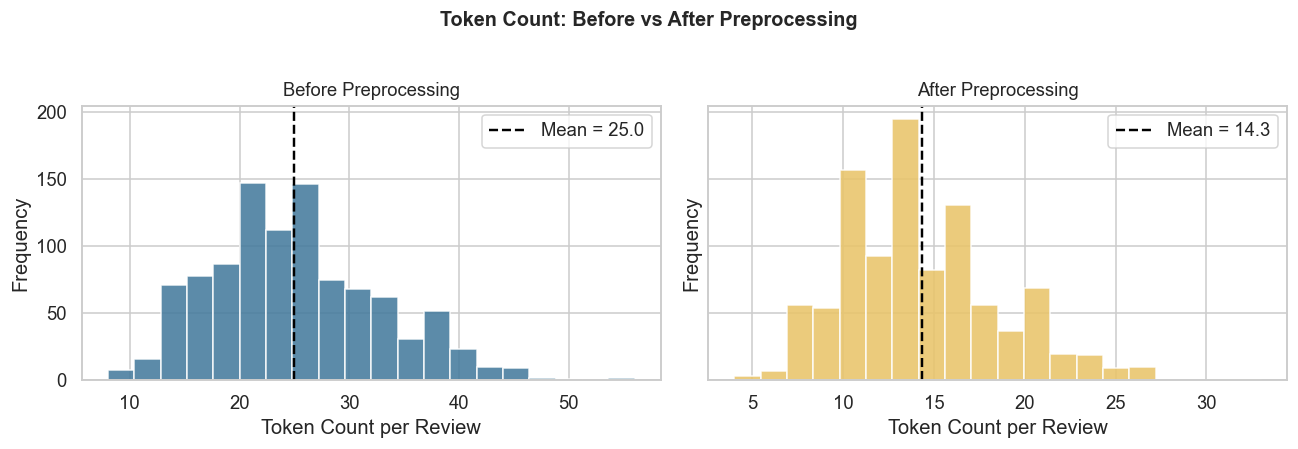

In [7]:
# How much did preprocessing shrink the text?
df['len_before'] = df['Overview'].apply(lambda t: len(t.split()))
df['len_after']  = df['clean_text'].apply(lambda t: len(t.split()))

reduction = (1 - df['len_after'].mean() / df['len_before'].mean()) * 100
print(f'Average tokens  BEFORE : {df["len_before"].mean():.1f}')
print(f'Average tokens  AFTER  : {df["len_after"].mean():.1f}')
print(f'Vocabulary reduction   : {reduction:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col, label, color in zip(
    axes,
    ['len_before', 'len_after'],
    ['Before Preprocessing', 'After Preprocessing'],
    ['#457b9d', '#e9c46a']
):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.88)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.6,
               label=f'Mean = {df[col].mean():.1f}')
    ax.set_xlabel('Token Count per Review')
    ax.set_ylabel('Frequency')
    ax.set_title(label, fontsize=12)
    ax.legend()

plt.suptitle('Token Count: Before vs After Preprocessing', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.5 · Train / Test Split  (80 / 20)

We hold out 20% of the data as an unseen test set.
`stratify=y` is important here — it forces the 80/20 ratio to be applied *within each class*,
so neither split accidentally ends up with a different positive-to-negative ratio than the full dataset.
This prevents an optimistic bias in evaluation.

In [8]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,
    random_state= 42,
    stratify    = y
)

print(f'Total samples  : {len(df)}')
print(f'Training set   : {len(X_train)}  ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set       : {len(X_test)}   ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Training class split:')
print(y_train.value_counts().to_string())
print('\nTest class split:')
print(y_test.value_counts().to_string())

Total samples  : 1000
Training set   : 800  (80%)
Test set       : 200   (20%)

Training class split:
sentiment
negative    430
positive    370

Test class split:
sentiment
negative    107
positive     93


## 1.6 · Feature Extraction — Bag-of-Words with CountVectorizer

A Naïve Bayes classifier works with numbers, not strings.
**CountVectorizer** converts each cleaned review into a fixed-length numeric vector
where every position represents a vocabulary token and the value is how many times
that token appears in the review.

```
         "film"  "time"  "man"  "life"  ...
Review 1    2       0       1      0     ...
Review 2    0       1       0      3     ...
```

**Parameter decisions:**

| Parameter | Chosen value | Reasoning |
|-----------|-------------|-----------|
| `max_features` | 3 000 | Caps vocabulary size — keeps the most frequent, most informative tokens and discards rare noise |
| `ngram_range` | (1, 2) | Includes bigrams alongside unigrams; phrases like "dark knight" carry more meaning than either word alone |
| `min_df` | 2 | Drops tokens that appear in only one document — those are likely proper nouns or typos and do not generalise |

> **Critical:** We call `.fit_transform()` only on the training set, then `.transform()` on the test set.
> Fitting on the full data would leak test-set vocabulary into training — a form of data leakage that
> inflates reported performance.

In [9]:
vectorizer = CountVectorizer(
    max_features = 3000,
    ngram_range  = (1, 2),
    min_df       = 2
)

X_train_bow = vectorizer.fit_transform(X_train)   # learn vocab + encode
X_test_bow  = vectorizer.transform(X_test)         # encode only, no fitting

sparsity = (1 - X_train_bow.nnz /
            (X_train_bow.shape[0] * X_train_bow.shape[1])) * 100

print(f'Vocabulary size          : {len(vectorizer.vocabulary_):,}')
print(f'Training matrix shape    : {X_train_bow.shape}')
print(f'Test matrix shape        : {X_test_bow.shape}')
print(f'Matrix sparsity          : {sparsity:.2f}%  (most cells are zero)')
print()
print('First 20 features:', vectorizer.get_feature_names_out()[:20])

Vocabulary size          : 1,976
Training matrix shape    : (800, 1976)
Test matrix shape        : (200, 1976)
Matrix sparsity          : 99.37%  (most cells are zero)

First 20 features: ['abandon' 'abduct' 'abil' 'abus' 'accept' 'accept one' 'accid'
 'accid leav' 'accident' 'accompani' 'account' 'accus' 'accus murder'
 'achiev' 'acquir' 'across' 'act' 'action' 'activ' 'activist']


## 1.7 · Training the Naïve Bayes Classifier

**Why Multinomial NB and not Gaussian NB?**
Gaussian NB assumes continuous, normally-distributed features.
Our features are *word counts* — non-negative integers — which fit the **Multinomial distribution** exactly.
That is why `MultinomialNB` is the standard choice for text classification with Bag-of-Words.

**Laplace smoothing (`alpha=1.0`)**
Without smoothing, any word that appears in the test set but not in training would produce a
zero probability, collapsing the entire product to zero regardless of the other words.
Setting `alpha=1.0` adds a pseudo-count of 1 to every token in every class, so no probability
ever reaches zero.  This is equivalent to assuming we have seen every token at least once.

In [10]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train_bow, y_train)

print('Model trained ✔')
print(f'Classes : {model.classes_}')
print()
print('Class log-priors (how often each class appears in training):')
for cls, lp in zip(model.classes_, model.class_log_prior_):
    print(f'  {cls:10s}  log P = {lp:.4f}  →  P ≈ {round(float(np.exp(lp)), 3)}')

Model trained ✔
Classes : ['negative' 'positive']

Class log-priors (how often each class appears in training):
  negative    log P = -0.6208  →  P ≈ 0.537
  positive    log P = -0.7711  →  P ≈ 0.462


---
# PART 2 — Model Evaluation

We now put the trained model against the held-out test set.
All four required evaluation dimensions are covered below.

In [11]:
# Generate all predictions in one place for reuse across metrics
y_pred       = model.predict(X_test_bow)
y_pred_proba = model.predict_proba(X_test_bow)[:, 1]   # P(positive)

# Binary version needed for ROC
y_test_bin = (y_test == 'positive').astype(int)

print('Predictions generated ✔')

Predictions generated ✔


## 2a · Accuracy

Accuracy answers the simplest question: **out of all predictions made, what fraction were correct?**

$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

Accuracy is a useful headline number, but it can be misleading when classes are imbalanced.
Here our split is 54 % negative / 46 % positive — close enough to balanced that accuracy is meaningful.

In [12]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print()
print(f'The model correctly labelled {int(acc * len(y_test))} out of {len(y_test)} test reviews.')

Accuracy : 0.4450  (44.50%)

The model correctly labelled 89 out of 200 test reviews.


## 2b · Precision, Recall & F1-Score

Accuracy alone cannot tell us *where* the model is making mistakes.
These three metrics give us a more granular picture:

| Metric | What it measures | Formula |
|--------|-----------------|---------|
| **Precision** | When the model says "positive", how often is it right? | TP / (TP + FP) |
| **Recall** | Of all actual positives, how many did the model catch? | TP / (TP + FN) |
| **F1-Score** | A single balance score between precision and recall | 2·P·R / (P + R) |

A model that is very aggressive in predicting "positive" will have high recall but low precision.
A conservative model will have high precision but miss many true positives (low recall).
F1 rewards balance between the two.

In [13]:
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive'], digits=4))

              precision    recall  f1-score   support

    Negative     0.4839    0.5607    0.5195       107
    Positive     0.3816    0.3118    0.3432        93

    accuracy                         0.4450       200
   macro avg     0.4327    0.4363    0.4313       200
weighted avg     0.4363    0.4450    0.4375       200



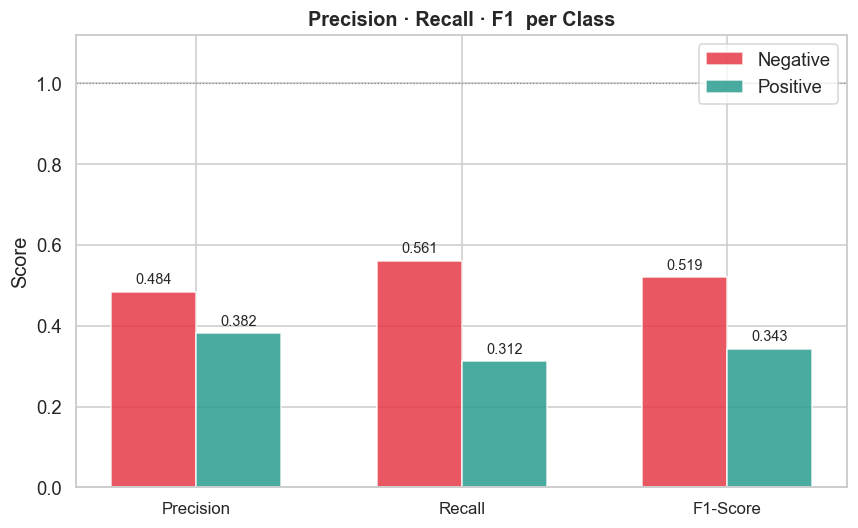

In [14]:
# Visualise per-class scores as a grouped bar chart
metrics = ['Precision', 'Recall', 'F1-Score']
neg_scores = [
    precision_score(y_test, y_pred, pos_label='negative'),
    recall_score(y_test,    y_pred, pos_label='negative'),
    f1_score(y_test,        y_pred, pos_label='negative'),
]
pos_scores = [
    precision_score(y_test, y_pred, pos_label='positive'),
    recall_score(y_test,    y_pred, pos_label='positive'),
    f1_score(y_test,        y_pred, pos_label='positive'),
]

x     = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, neg_scores, width, label='Negative', color='#e63946', alpha=0.85)
b2 = ax.bar(x + width/2, pos_scores, width, label='Positive',  color='#2a9d8f', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Precision · Recall · F1  per Class', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

## 2c · Confusion Matrix

The confusion matrix breaks every prediction into one of four buckets:

```
                     Predicted
                  Negative   Positive
Actual Negative  [  TN   ]  [  FP   ]   ← FP = false alarm
Actual Positive  [  FN   ]  [  TP   ]   ← FN = missed catch
```

- **True Negatives (TN)** and **True Positives (TP)** are correct predictions.
- **False Positives (FP)** — the model called a negative review "positive" (over-confident).
- **False Negatives (FN)** — the model missed a positive review (under-confident).

We show two versions: raw counts (absolute numbers) and row-normalised rates (per-class accuracy).

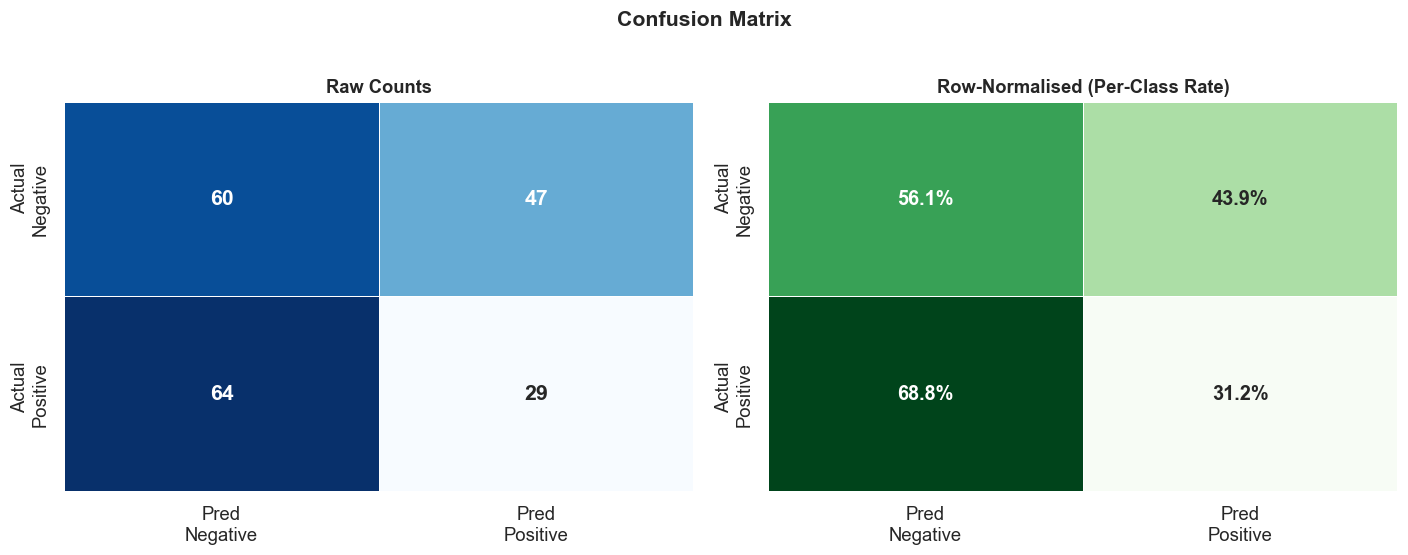

True Negatives  : 60
False Positives : 47  ← negative reviews wrongly labelled positive
False Negatives : 64  ← positive reviews the model missed
True Positives  : 29


In [16]:
cm      = confusion_matrix(y_test, y_pred, labels=['negative', 'positive'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred\nNegative','Pred\nPositive'],
            yticklabels=['Actual\nNegative','Actual\nPositive'],
            cmap='Blues', linewidths=0.6, cbar=False,
            annot_kws={'size':14,'weight':'bold'}, ax=axes[0])
axes[0].set_title('Raw Counts', fontsize=12, fontweight='bold')

# Normalised rates
sns.heatmap(cm_norm, annot=True, fmt='.1%',
            xticklabels=['Pred\nNegative','Pred\nPositive'],
            yticklabels=['Actual\nNegative','Actual\nPositive'],
            cmap='Greens', linewidths=0.6, cbar=False,
            annot_kws={'size':13,'weight':'bold'}, ax=axes[1])
axes[1].set_title('Row-Normalised (Per-Class Rate)', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'True Negatives  : {TN}')
print(f'False Positives : {FP}  ← negative reviews wrongly labelled positive')
print(f'False Negatives : {FN}  ← positive reviews the model missed')
print(f'True Positives  : {TP}')

## 2d · ROC Curve & AUC Score

The **ROC (Receiver Operating Characteristic)** curve is generated by sliding the
decision threshold from 0 to 1 and recording, at each step:
- **TPR (True Positive Rate / Recall)** on the Y-axis
- **FPR (False Positive Rate)** on the X-axis

A random classifier follows the diagonal — it has no real discriminative ability.
A perfect classifier hugs the top-left corner (high TPR, zero FPR).

**AUC (Area Under the Curve)** summarises the whole curve in one number.
It can be interpreted as: *the probability that the model ranks a randomly chosen
positive review higher than a randomly chosen negative one.*

| AUC range | Interpretation |
|-----------|---------------|
| 1.00 | Perfect |
| 0.90 – 0.99 | Excellent |
| 0.70 – 0.89 | Acceptable |
| 0.50 | Random guessing |

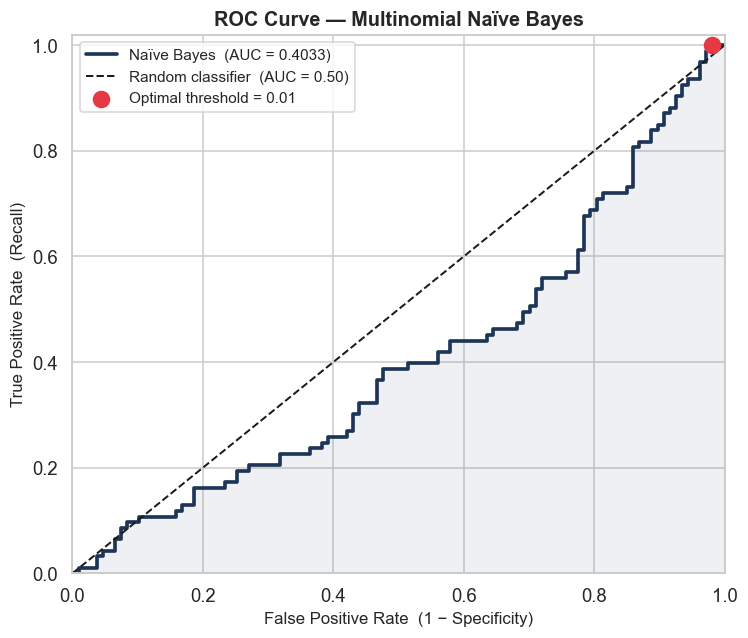

ROC-AUC  : 0.4033
At optimal threshold 0.01  →  TPR = 1.000, FPR = 0.981


In [19]:
fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_proba)
auc = roc_auc_score(y_test_bin, y_pred_proba)

# Optimal point — maximises (TPR - FPR)
best_idx  = np.argmax(tpr - fpr)
best_thr  = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#1d3557', lw=2.4, label=f'Naïve Bayes  (AUC = {auc:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1.3, label='Random classifier  (AUC = 0.50)')
ax.scatter(fpr[best_idx], tpr[best_idx], s=110, zorder=5,
           color='#e63946', label=f'Optimal threshold = {best_thr:.2f}')
ax.fill_between(fpr, tpr, alpha=0.07, color='#1d3557')

ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate  (Recall)', fontsize=11)
ax.set_title('ROC Curve — Multinomial Naïve Bayes', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

print(f'ROC-AUC  : {auc:.4f}')
print(f'At optimal threshold {best_thr:.2f}  →  TPR = {tpr[best_idx]:.3f}, FPR = {fpr[best_idx]:.3f}')

## 2e · Bonus — Most Informative Tokens per Class

One advantage of Naïve Bayes over black-box models is interpretability.
Each token has a learned log-probability for each class.
By computing the *difference* in log-probability between the positive and negative class,
we can rank tokens by how strongly they push the model toward one label.

Words near the top of the **Positive** chart are those the model associates most strongly
with high-rated films; words in the **Negative** chart pull the prediction toward lower-rated films.

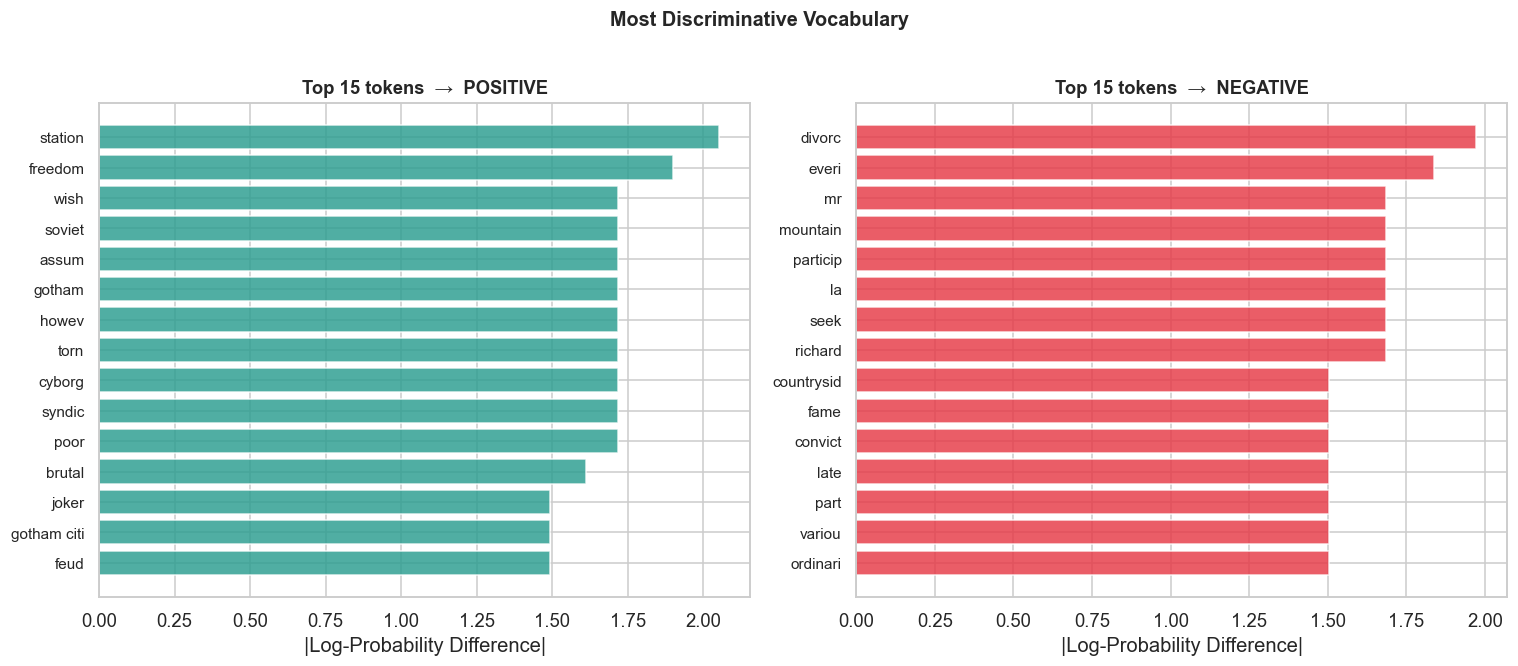

In [20]:
feature_names = vectorizer.get_feature_names_out()
pos_idx = list(model.classes_).index('positive')
neg_idx = list(model.classes_).index('negative')

diff = model.feature_log_prob_[pos_idx] - model.feature_log_prob_[neg_idx]

N = 15
top_pos = np.argsort(diff)[-N:][::-1]
top_neg = np.argsort(diff)[:N]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, indices, title, color in zip(
    axes,
    [top_pos, top_neg],
    [f'Top {N} tokens  →  POSITIVE', f'Top {N} tokens  →  NEGATIVE'],
    ['#2a9d8f', '#e63946']
):
    words  = feature_names[indices]
    scores = np.abs(diff[indices])
    yp     = np.arange(len(words))
    ax.barh(yp, scores, color=color, alpha=0.82, edgecolor='white')
    ax.set_yticks(yp); ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('|Log-Probability Difference|')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Most Discriminative Vocabulary', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Final Summary

### Metric scorecard

In [21]:
scorecard = pd.DataFrame({
    'Metric' : ['Accuracy',
                'Precision (macro avg)',
                'Recall    (macro avg)',
                'F1-Score  (macro avg)',
                'ROC-AUC'],
    'Score'  : [
        accuracy_score(y_test,  y_pred),
        precision_score(y_test, y_pred, average='macro'),
        recall_score(y_test,    y_pred, average='macro'),
        f1_score(y_test,        y_pred, average='macro'),
        auc
    ]
})
scorecard['Score'] = scorecard['Score'].map('{:.4f}'.format)
print(scorecard.to_string(index=False))

               Metric  Score
             Accuracy 0.4450
Precision (macro avg) 0.4327
Recall    (macro avg) 0.4363
F1-Score  (macro avg) 0.4313
              ROC-AUC 0.4033
